# Prueba de Kruskal-Wallis (parte 2)

Supongamos que como Científicos de Datos estamos evaluando el rendimiento de una API de un Modelo de Machine Learning desplegada en 3 servidores distintos: AWS, Azure y Google Cloud.

Recolectamos datos por cada servidor y medimos en cada caso el tiempo de respuesta (en ms). 

**¿El tipo de servidor afecta el tiempo de respuesta de la API?**

## 1. Desarrollo de la prueba de hipótesis

- En este caso tenemos 1 factor (el tipo de servidor) con tres niveles (AWS/A, Azure/B, Google Cloud/C)
- Y **en principio** el tiempo de respuesta es la variable a comparar

### 1.1. Paso 1: definir el problema del negocio

> **¿Hay diferencias entre los tiempos de respuesta de los tres servidores?**

### 1.2. Paso 2: redactar el problema del negocio como un problema de Ciencia de Datos/Machine Learning

> **¿Existen diferencias estadísticamente significativas entre los tiempos de respuesta de los tres servidores?**

### 1.3. Paso 3: definir $H_0$ y $H_1$

- $H_0$: los tiempos de respuesta en los tres servidores son **iguales**
- $H_1$: los tiempos de respuesta en los tres servidores son **diferentes**

### 1.4. Paso 4: definir $\alpha$

Asumiremos un nivel de significancia $\alpha = 0.05$.

### 1.5. Paso 5: definir la potencia de la prueba ($1-\beta$) y el tamaño de las muestras ($n$)

Acá la lógica es muy similar a la que vimos en las lecciones anteriores, con algunos ligeros cambios.

1. Definimos el tamaño del efecto. En el caso de la prueba Kruskal-Wallis, el tamaño del efecto se define como:

$$\epsilon^2 = \frac{H}{N-1}$$

Y esta es la manera de interpretarlo:

- $\epsilon^2 \leq 0.08 \rightarrow \text{efecto "pequeño"}$
- $\epsilon^2 \leq 0.26 \rightarrow \text{efecto "mediano"}$
- $\epsilon^2 > 0.26 \rightarrow \text{efecto "grande"}$

2. Definimos la potencia de la prueba esperada (probabilidad entre 0 y 1)
3. Usamos "FTestAnovaPower" de "Scipy" para calcular el tamaño de las muestras pero:
    - Definimos como tamaño del efecto el valor ajustado a la prueba ANOVA: $f=\sqrt{\frac{\epsilon^2}{1-\epsilon^2}}$
    - Lo anterior nos arroja el tamaño de la muestra para ANOVA. Para obtener el tamaño de la muestra para Kruskal-Wallis usamos la aproximación $n_{\text{KW}} \approx \frac{n_{\text{ANOVA}}}{0.85}$


Asumiremos entonces:

- $\epsilon^2 = 0.2$, es decir un tamaño del efecto "mediano-grande"
- Potencia de la prueba igual a 0.9

Veamos cómo estimar el tamaño de la muestra para cada grupo

In [1]:
from statsmodels.stats.power import FTestAnovaPower
import math

# Diseño del experimento
e2 = 0.4     # Tamaño del efecto
alpha = 0.05 # Nivel de significancia
power = 0.9  # Potencia de la prueba
N = 3        # Número de grupos (A, B y C)

# Instancia de FTestAnovaPower
analisis = FTestAnovaPower()

# ANOVA: cálculo del número de muestras por grupo
f_anova = math.sqrt(e2/(1-e2)), #<------ Tamaño del efecto ajustado
n_anova = analisis.solve_power(
    effect_size=f_anova[0],
    alpha=alpha, 
    power=power, 
    k_groups=N
)

# Kruskal-Wallis: ajuste del número de muestras
n = math.ceil(n_anova / 0.85)

print(f"Tamaño efecto ANOVA equivalente: {f_anova[0]:.2f}")
print(f"Tamaño de la muestra ANOVA: {math.ceil(n_anova)}")
print(f"Tamaño de la muestra Kruskal-Wallis: {n}")
print(f"Tamaño mínimo de la muestra por cada grupo: {n}")

Tamaño efecto ANOVA equivalente: 0.82
Tamaño de la muestra ANOVA: 23
Tamaño de la muestra Kruskal-Wallis: 27
Tamaño mínimo de la muestra por cada grupo: 27


Es decir que:

> **Necesitamos recolectar al menos 23/27 muestras (ANOVA/Kruskal-Wallis) por grupo  para tener un tamaño del efecto esperado de 0.82/0.2, un nivel de significancia de 0.05 y una potencia de la prueba de 0.9**

### 1.6. Paso 6: recolectar y preparar los datos

Supondremos que ya hemos recolectado los datos. Estos se encuentran en el dataset "dataset_kruskal_wallis.csv":

In [2]:
import pandas as pd

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/46-2026-04-EstadisticaInferencialNoParametrica/data/'

datos = pd.read_csv(RUTA + 'dataset_kruskal_wallis.csv')
datos

,A,B,C
0,17.4,44.1,28.9
1,19.1,48.6,25.1
2,13.7,47.3,33.3
3,21.2,47.5,24.4
4,20.4,47.4,28.0
...,...,...,...
395,16.4,41.2,34.3
396,17.9,49.9,25.4
397,15.4,45.4,25.8
398,14.7,40.1,25.8


Por cada variable tenemos 400 registros, que en ambos casos superan la cantidad que estimamos hace un momento.

Veamos cómo están distribuidas estas variables, lo cual nos permitirá determinar si aplicamos ANOVA o Kruskal-Wallis.

Dibujemos los histogramas de las tres variables:

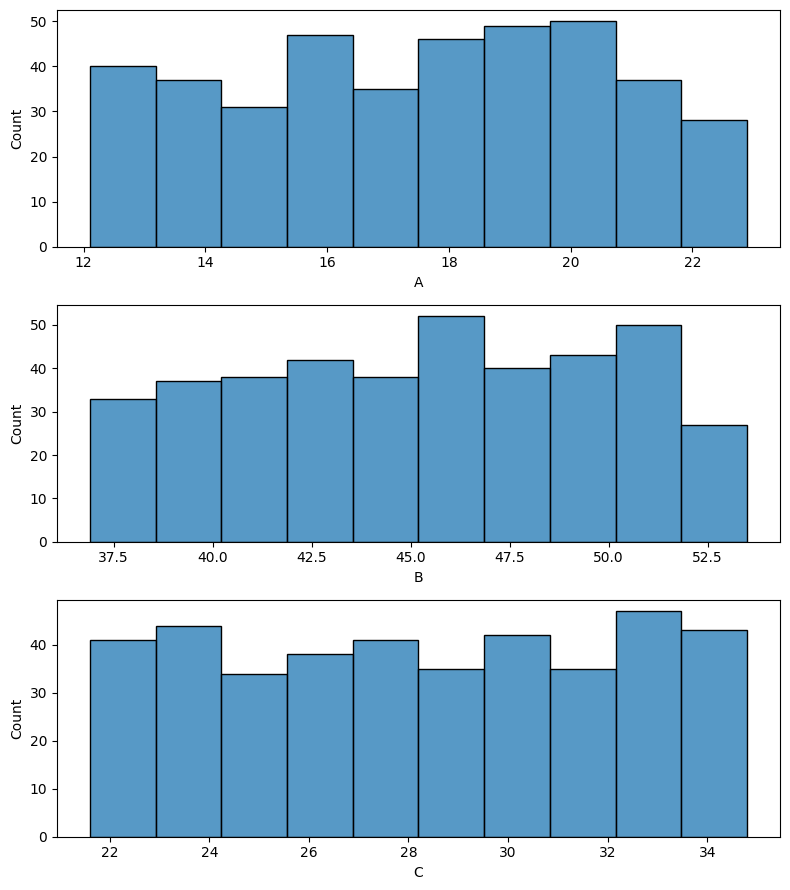

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(3,1,figsize=(8,9))

sns.histplot(datos['A'],ax=axs[0])
sns.histplot(datos['B'],ax=axs[1])
sns.histplot(datos['C'],ax=axs[2])
plt.tight_layout()

Al parecer las distribuciones no son normales. Veamos qué ocurre con la prueba de Shapiro:

In [4]:
from scipy.stats import shapiro

for grupo in ['A','B','C']:
    W, p_shapiro = shapiro(datos[grupo])
    
    print(f"Grupo {grupo} - p = {p_shapiro}")
    
    

Grupo A - p = 9.63472872828772e-09
Grupo B - p = 1.3076008447368366e-08
Grupo C - p = 1.175414746803753e-10


Y evemos que efectivamente las distribuciones son no normales, así que debemos aplicar la prueba de Kruskal-Wallis.

### 1.7. Paso 7: aplicar la prueba estadística para obtener el valor p

En este caso usaremos la función "anova" de la librería Pingouin. Primero debemos pasar de la tabla en formato ancho ("wide") a formato largo ("long"):

In [5]:
datos_largo = datos.melt(var_name="servidor", value_name="tiempo")
datos_largo

,servidor,tiempo
0,A,17.4
1,A,19.1
2,A,13.7
3,A,21.2
4,A,20.4
...,...,...
1195,C,34.3
1196,C,25.4
1197,C,25.8
1198,C,25.8


Y ahora sí aplicamos la prueba:

In [6]:
from pingouin import kruskal

resultados = kruskal(
    data = datos_largo,
    dv = 'tiempo', # Variable numérica
    between = 'servidor', # El factor
    )
resultados

,Source,ddof1,H,p-unc
Kruskal,servidor,2,1061.240678,3.585212e-231


Acá tenemos:

- "Source": el factor de la prueba (la columna "servidor" que contiene los diferentes grupos)
- "ddof1": los grados de libertad (número de grupos - 1 = 2)
- "H": la estadística de la prueba
- "p-unc": el valor p (¡prácticamente igual a cero!)

Con el valor p obtenido ya podemos intuir que se puede rechazar la hipótesis nula.

### 1.8. Paso 8: aceptar o rechazar $H_0$

Y con las pruebas anteriores, incluyendo el valor p de $3.6x10^{-231}$ podemos rechazar la hipótesis nula (tiempos de respuesta iguales) y nos inclinamos por $H_1$ (tiempos de respuesta diferentes).

Y por tanto:

> Existen diferencias estadísticamente significativas en los tiempos de respuesta en los tres servidores

Es decir que ¡el tipo de servidor SÍ influye en el tiempo de respuesta de la API!

### 1.9. Paso 9: evaluar el tamaño del efecto y la potencia de la prueba actualizadas

En este caso podemos calcular el tamaño del efecto a partir de la fórmula:

In [7]:
N = len(datos)*3 # Cantidad total de datos (1200)
e2_ph = resultados['H'].values[0]/(N-1) # H/(N-1)
e2_ph

0.8851048187895717

Así que tenemos un tamaño del efecto grande, lo cual evidencia que efectivamente los tiempos de respuesta son muy diferentes entre servidores.

Finalmente calculemos la potencia de la prueba post-hoc usando "FTestAnovaPower()" de "statsmodels":

Y ahora calculemos la potencia de la prueba con "statsmodels":

In [8]:
# Instancia
import math
analisis = FTestAnovaPower()

# Calcular potencia
f_cohen = math.sqrt(e2/(1-e2))
potencia = analisis.power(
    effect_size = f_cohen, # El tamaño F-Cohen que acabamos de calcular
    nobs = len(datos), # El tamaño de la muestra (por cada grupo) (400)
    alpha = alpha, # El nivel de significancia definido anteriormente para la prueba (0.05)
    k_groups = 3, # El número de subniveles del factor (el número de grupos)
)
potencia

1.0